# Network-Centric Feature Engineering for Cross-Asset Statistical Arbitrage

This project tests a market-neutral statistical arbitrage strategy, but with a few changes. I used graphs to represent the entire stock market as a connected network and to observe how the movement of influential assets affect the movements of stocks around them. I also use PCA to minimize systematic risk and help predictive signals stand out from noise, and created a Ridge regression model to process the data and execute a market-neutral, long-short portfolio.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
import yfinance as yf

## Step 1: Preprocessing
I took 24 large-cap equities across different sectors, along with the SPY ETF to use as the market benchmark. I then calculated daily log returns to stabilize variance and ensure time-additivity:
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [15]:
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', # Tech Sector
    'JPM', 'BAC', 'GS', 'MS',                              # Financials Sector
    'JNJ', 'UNH', 'PFE', 'ABBV',                           # Healthcare Sector
    'XOM', 'CVX',                                          # Energy Sector
    'WMT', 'PG', 'KO', 'PEP',                              # Consumer Def Sector
    'CAT', 'DE', 'BA',                                     # Industrials Sector
    'SPY'                                                  # Benchmark
]
data = yf.download(tickers, start="2014-01-01", end="2024-01-01")["Close"]

# Calculate log returns and separate benchmark
log_returns = np.log(data / data.shift(1)).dropna()
spy_returns = log_returns['SPY']
stock_returns = log_returns.drop(columns=['SPY'])
stock_returns = stock_returns.clip(lower=stock_returns.quantile(0.01), upper=stock_returns.quantile(0.99), axis=1)

C:\Users\jlh68\AppData\Local\Temp\ipykernel_24532\2458695550.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2014-01-01", end="2024-01-01")["Close"]
[*********************100%***********************]  25 of 25 completed


## Step 2: Feature Engineering
I made a rolling 60-day Pearson correlation matrix with a threshold ($\tau = 0.5$) and put this into an adjacency matrix $A$ representing the market network.

I then created two features for each asset $i$:
* **Degree Centrality:** $D_i^{(t)} = \sum_{j} A_{i,j}^{(t)}$
* **Neighbor Momentum:** $M_i^{(t)} = \frac{1}{D_i^{(t)}} \sum_{j} A_{i,j}^{(t)} R_j^{(5)}$

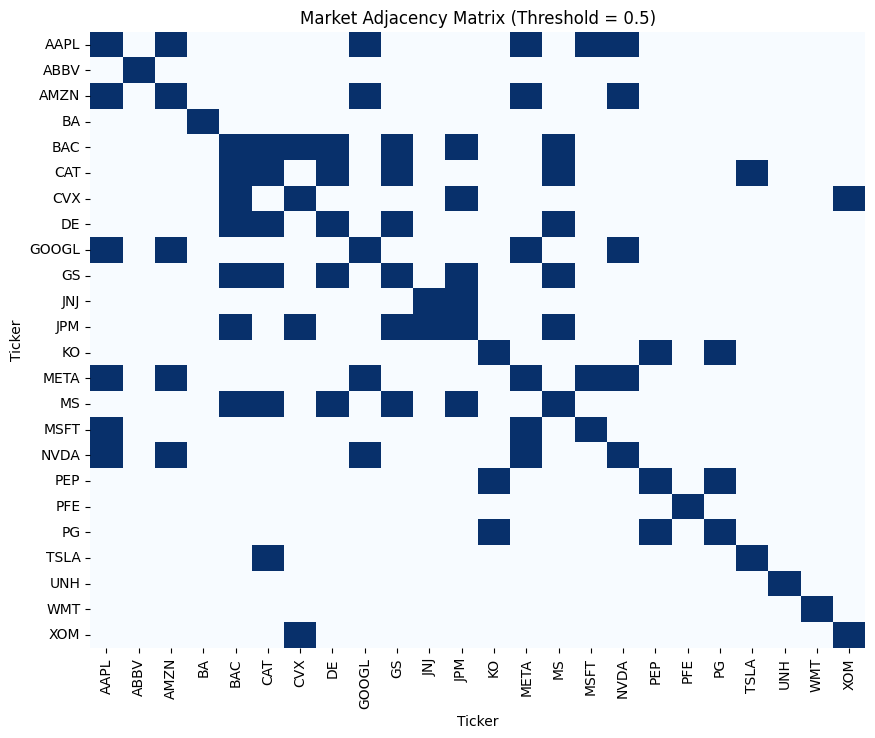

In [16]:
rolling_window = 60          
threshold = 0.5     

degree_centrality = pd.DataFrame(index=stock_returns.index, columns=stock_returns.columns)
neighbor_momentum = pd.DataFrame(index=stock_returns.index, columns=stock_returns.columns)

rolling_returns = stock_returns.rolling(window=5).sum()

for i in range(rolling_window, len(stock_returns)):
    window_data = stock_returns.iloc[i-rolling_window : i]
    corr_matrix = window_data.corr().values
    np.fill_diagonal(corr_matrix, 0)
    adjacency = (corr_matrix > threshold).astype(int)
    degrees = adjacency.sum(axis=1)
    current_returns = rolling_returns.iloc[i-1].values
    safe_degrees = np.where(degrees == 0, 1, degrees)
    neighbors_momentum = np.dot(adjacency, current_returns) / safe_degrees
    date_idx = stock_returns.index[i]
    degree_centrality.loc[date_idx] = degrees
    neighbor_momentum.loc[date_idx] = neighbors_momentum
degree_centrality = degree_centrality.dropna().astype(float)
neighbor_momentum = neighbor_momentum.dropna().astype(float)
latest_corr = stock_returns.iloc[-rolling_window:].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(latest_corr > threshold, cmap='Blues', cbar=False)
plt.title(f"Market Adjacency Matrix (Threshold = {threshold})")
plt.show()

## Step 3: PCA Orthogonalization
To guarantee idiosyncratic alpha, I use PCA to extract the first principal component, the empirical market factor, and subtracted this from our actual returns to identify the residual returns.

In [17]:
def get_residual_returns(returns_df):
    pca = PCA(n_components=1)
    market_factor = pca.fit_transform(returns_df)
    market_reconstruction = pca.inverse_transform(market_factor)
    residuals = returns_df - market_reconstruction
    return pd.DataFrame(residuals, index=returns_df.index, columns=returns_df.columns)
residual_returns = get_residual_returns(stock_returns.loc[degree_centrality.index])
target_returns = residual_returns.shift(-1).dropna()

## 4. Expanding Window Predictive Model & Backtest
I use an expanding-window Ridge regression to prevent overfitting to collinear financial data and to dynamically predict $t+1$ returns. I long the top 20% of predicted assets and short the bottom 20%, equally weighted.

In [12]:
aligned_idx = target_returns.index.intersection(degree_centrality.index).intersection(neighbor_momentum.index)
degree_df = degree_centrality.loc[aligned_idx]
neighbor_momentum_df = neighbor_momentum.loc[aligned_idx]
targets = target_returns.loc[aligned_idx]
portfolio_returns = []
prediction_dates = []

for t in range(500, len(aligned_idx) - 1):
    # Train
    X_train_degree = degree_df.iloc[:t].values.flatten()
    X_train_momentum = neighbor_momentum_df.iloc[:t].values.flatten()
    y_train = targets.iloc[:t].values.flatten()
    X_train = np.column_stack((zscore(X_train_degree), zscore(X_train_momentum)))
    
    m = Ridge(alpha=1.0)
    m.fit(X_train, y_train)
    X_test_degree = degree_df.iloc[t].values
    X_test_momentum = neighbor_momentum_df.iloc[t].values
    X_test = np.column_stack((zscore(X_test_degree), zscore(X_test_momentum)))
    preds = m.predict(X_test)
    pred_series = pd.Series(preds, index=targets.columns)
    
    quantiles = pred_series.quantile([0.2, 0.8])
    longs = pred_series[pred_series >= quantiles[0.8]].index
    shorts = pred_series[pred_series <= quantiles[0.2]].index
    
    actual_next_day_returns = stock_returns.loc[aligned_idx[t+1]]
    long_returns = actual_next_day_returns[longs].mean() if len(longs) > 0 else 0
    short_returns = actual_next_day_returns[shorts].mean() if len(shorts) > 0 else 0
    
    strat_returns = (long_returns - short_returns) / 2 
    portfolio_returns.append(strat_returns)
    prediction_dates.append(aligned_idx[t+1])

strat_series = pd.Series(portfolio_returns, index=prediction_dates)

## 5. Performance
I evaluate the strategy's out-of-sample performance against the SPY benchmark and visualize cumulative returns and computing the annualized Sharpe Ratio.

Annualized Return: 2.58%
Annualized Volatility: 10.42%
Sharpe Ratio: 0.25


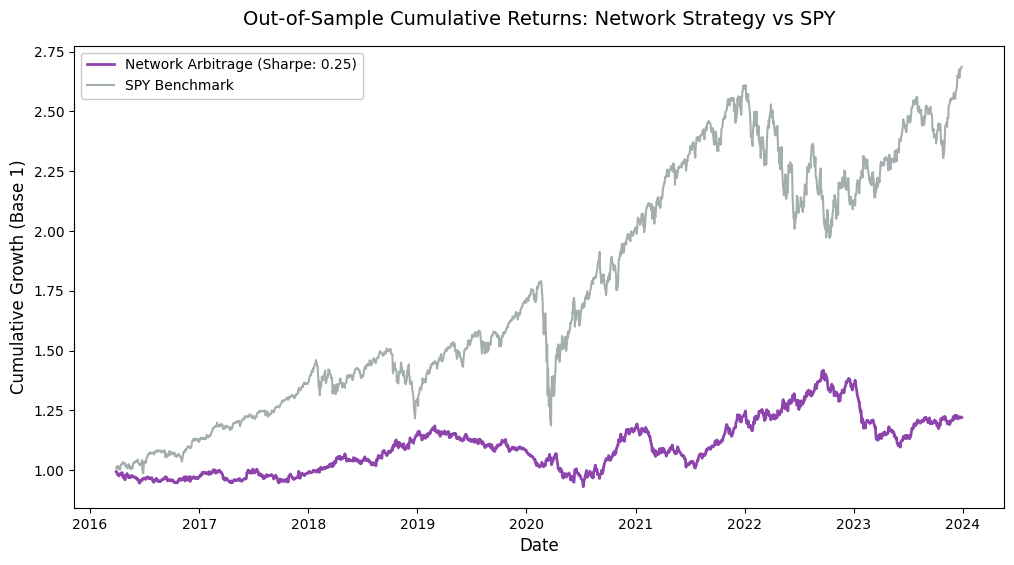

In [18]:
cumulative_strat = np.exp(strat_series.cumsum())
cumulative_spy = np.exp(spy_returns.loc[prediction_dates].cumsum())

ann_return = strat_series.mean() * 252
ann_vol = strat_series.std() * np.sqrt(252)
sharpe = ann_return / ann_vol if ann_vol != 0 else 0
print(f"Annualized Return: {ann_return:.2%}")
print(f"Annualized Volatility: {ann_vol:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(cumulative_strat, label=f"Network Arbitrage (Sharpe: {sharpe:.2f})", color='#8E44AD', linewidth=2)
plt.plot(cumulative_spy, label="SPY Benchmark", color='#7F8C8D', alpha=0.7, linewidth=1.5)
plt.title("Out-of-Sample Cumulative Returns: Network Strategy vs SPY", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Growth (Base 1)", fontsize=12)
plt.legend(frameon=True, facecolor='white', framealpha=1)
plt.show()